In [85]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [86]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 10
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8.5})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = True

In [87]:
results_file = 'overall_results_burden_shifting.xlsx'

In [88]:
hh_one_five_step_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'hh_1-step_vs_5-step', index_col = 0)
hh_one_five_step_df_final = hh_one_five_step_df.drop(columns = ['Total', 'Impact 2050', 'Low', 'High', 'STDEV'])

es_one_five_step_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'es_1-step_vs_5-step', index_col = 0)
es_one_five_step_df_final = es_one_five_step_df.drop(columns = ['Total', 'Impact 2050', 'Low', 'High', 'STDEV'])

nr_one_five_step_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'nr_1-step_vs_5-step', index_col = 0)
nr_one_five_step_df_final = nr_one_five_step_df.drop(columns = ['Total', 'Impact 2050', 'Low', 'High', 'STDEV'])
nr_one_five_step_df_final

,Scenario,Ammonia,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,1-step,0.205921,0.001438,0.000000,0.000094,0,7.237043e-09
1,5-step,0.225041,0.015658,0.002633,0.000229,0,0.000000e+00
2,1-step,0.044282,0.001438,0.000000,0.000094,0,7.237043e-09
3,5-step,0.048394,0.015658,0.002633,0.000229,0,0.000000e+00


In [89]:
hh_N_H_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'hh_N_vs_H', index_col = 0)
hh_N_H_df_final = hh_N_H_df.drop(columns = ['Total', 'Impact 2050', 'Low', 'High', 'STDEV'])
hh_N_H_df_final

es_N_H_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'es_N_vs_H', index_col = 0)
es_N_H_df_final = es_N_H_df.drop(columns = ['Total', 'Impact 2050', 'Low', 'High', 'STDEV'])
es_N_H_df_final

nr_N_H_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'nr_N_vs_H', index_col = 0)
nr_N_H_df_final = nr_N_H_df.drop(columns = ['Total', 'Impact 2050', 'Low', 'High', 'STDEV'])
nr_N_H_df_final

,Scenario,Ammonia,Hydrogen,2-Ethylanthraquinone,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,N2O,0.205921,0.000000,0.000000,0.001438,0.000000,0.000094,0,7.237043e-09
1,H2O2,0.000000,0.091702,0.006964,0.002532,0.018048,0.000054,0,0.000000e+00
2,N2O,0.044282,0.000000,0.000000,0.001438,0.000000,0.000094,0,7.237043e-09
3,H2O2,0.000000,0.012969,0.006964,0.002532,0.018048,0.000054,0,0.000000e+00


In [90]:
x_pts_steps = np.arange(0, len(nr_one_five_step_df_final))
x_labels_steps = ['1-step', '5-step'] * 2
colors_steps = ['#f75e84', '#f8961e', '#f9c74f', '#90be6d', '#43aa8b', '#039cf0'] 

In [91]:
x_pts_N_H = np.arange(0, len(nr_N_H_df_final))
x_labels_N_H = ['N$_\mathdefault{2}$O', 'H$_\mathdefault{2}$O$_\mathdefault{2}$'] * 2
colors_N_H = ['#f75e84', '#f78c6b', '#ffd166', '#83d483', '#06d6a0', '#0cb0a9', '#039cf0', '#0073d2'] 

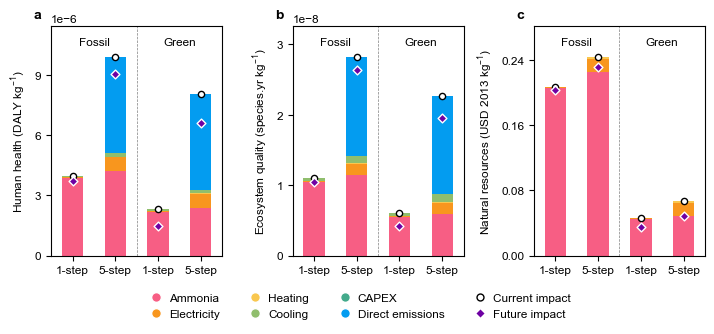

In [92]:
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize = (fig_length[2], fig_height*0.3))

hh_one_five_step_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_steps, alpha=1)
ax1.legend([], frameon = False)
ax1.set_ylabel('Human health (DALY kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_steps, hh_one_five_step_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder=2)
ax1.scatter(x_pts_steps, hh_one_five_step_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.set_title('a', fontweight='bold', x = -0.08, fontsize = fontsize_title)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax1.errorbar(
#     x_pts_steps,
#     hh_one_five_step_df['Total'],
#     yerr = (hh_one_five_step_df['Total'] - hh_one_five_step_df['Low'], hh_one_five_step_df['High'] - hh_one_five_step_df['Total']),
#     fmt = 'none',
#     ecolor = '#000000',
#     elinewidth = 0.75,
#     capsize = 3,
#     capthick = 0.75,
#     zorder = 1,
# )
# ax1.set_ylim([0.0, 2.0])
# ax1.text(0.5, 1.85, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(2.5, 1.85, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax1.yaxis.set_major_locator(MaxNLocator(4))
ax1.set_xticks(x_pts_steps)  
ax1.set_xticklabels(x_labels_steps, rotation = 0, ha = 'center')  
min_y, max_y = ax1.get_ylim()
ax1.set_ylim([min_y, max_y*1.1])
ax1.text(0.5, max_y*1.1*0.92, 'Fossil', ha = 'center', color = '#000000')
ax1.text(2.5, max_y*1.1*0.92, 'Green', ha = 'center', color = '#000000')

es_one_five_step_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors_steps, alpha=1)
ax2.legend([], frameon = False)
ax2.set_ylabel('Ecosystem quality (species.yr kg$^\mathdefault{-1}$)')
ax2.scatter(x_pts_steps, es_one_five_step_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder=2)
ax2.scatter(x_pts_steps, es_one_five_step_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax2.set_title('b', fontweight='bold', x = -0.08, fontsize = fontsize_title)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax2.errorbar(
#     x_pts_steps,
#     es_one_five_step_df['Total'],
#     yerr = (es_one_five_step_df['Total'] - es_one_five_step_df['Low'], es_one_five_step_df['High'] - es_one_five_step_df['Total']),
#     fmt = 'none',
#     ecolor = '#000000',
#     elinewidth = 0.75,
#     capsize = 3,
#     capthick = 0.75,
#     zorder = 1,
# )
# ax2.set_ylim([0, 4.5])
# ax2.text(0.5, 3.7, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax2.text(2.5, 3.7, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_xticks(x_pts_steps)  
ax2.set_xticklabels(x_labels_steps, rotation = 0, ha = 'center')  
min_y, max_y = ax2.get_ylim()
ax2.set_ylim([min_y, max_y*1.1])
ax2.text(0.5, max_y*1.1*0.92, 'Fossil', ha = 'center', color = '#000000')
ax2.text(2.5, max_y*1.1*0.92, 'Green', ha = 'center', color = '#000000')

nr_one_five_step_df_final.plot(kind = 'bar', stacked = True, ax = ax3, color = colors_steps, alpha=1)
ax3.legend([], frameon = False)
ax3.set_ylabel('Natural resources (USD 2013 kg$^\mathdefault{-1}$)')
ax3.scatter(x_pts_steps, nr_one_five_step_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder=2)
ax3.scatter(x_pts_steps, nr_one_five_step_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax3.set_title('c', fontweight='bold', x = -0.08, fontsize = fontsize_title)
ax3.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax3.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax3.errorbar(
#     x_pts_steps,
#     nr_one_five_step_df['Total'],
#     yerr = (nr_one_five_step_df['Total'] - nr_one_five_step_df['Low'], nr_one_five_step_df['High'] - nr_one_five_step_df['Total']),
#     fmt = 'none',
#     ecolor = '#000000',
#     elinewidth = 0.75,
#     capsize = 3,
#     capthick = 0.75,
#     zorder = 1,
# )
# ax3.set_ylim([0, 1.5])
# ax3.text(0.5, 1.2, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax3.text(2.5, 1.2, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax3.yaxis.set_major_locator(MaxNLocator(4))
ax3.set_xticks(x_pts_steps)
ax3.set_xticklabels(x_labels_steps, rotation = 0, ha = 'center')
min_y, max_y = ax3.get_ylim()
ax3.set_ylim([min_y, max_y*1.1])
ax3.text(0.5, max_y*1.1*0.92, 'Fossil', ha = 'center', color = '#000000')
ax3.text(2.5, max_y*1.1*0.92, 'Green', ha = 'center', color = '#000000')

labels = ['Ammonia', 'Electricity', 'Heating', 'Cooling', 'CAPEX', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7, alpha=1, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 4, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'burden_shifting', '1_step_vs_5_step_raw')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

# filepath = os.path.join('..', 'results', 'plots', 'edited', '1_step_vs_5_step_edited')
# plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
# plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

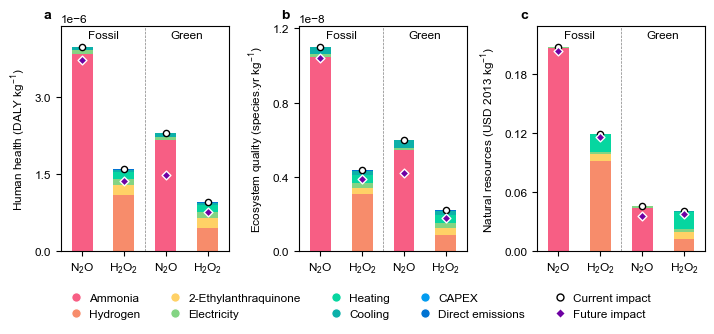

In [93]:
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize = (fig_length[2], fig_height*0.3))

hh_N_H_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_N_H, alpha=1)
ax1.legend([], frameon = False)
ax1.set_ylabel('Human health (DALY kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_N_H, hh_N_H_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder=2)
ax1.scatter(x_pts_N_H, hh_N_H_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.set_title('a', fontweight='bold', x = -0.08, fontsize = fontsize_title)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax1.errorbar(
#     x_pts_N_H,
#     hh_N_H_df['Total'],
#     yerr = (hh_N_H_df['Total'] - hh_N_H_df['Low'], hh_N_H_df['High'] - hh_N_H_df['Total']),
#     fmt = 'none',
#     ecolor = '#000000',
#     elinewidth = 0.75,
#     capsize = 3,
#     capthick = 0.75,
#     zorder = 1,
# )
# ax1.set_ylim([0.0, 2.4])
# ax1.text(0.5, 1.85, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(2.5, 1.85, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax1.yaxis.set_major_locator(MaxNLocator(4))
ax1.set_xticks(x_pts_N_H)  
ax1.set_xticklabels(x_labels_N_H, rotation = 0, ha = 'center')  
min_y, max_y = ax1.get_ylim()
ax1.set_ylim([min_y, max_y*1.1])
ax1.text(0.5, max_y*1.1*0.95, 'Fossil', ha = 'center', color = '#000000')
ax1.text(2.5, max_y*1.1*0.95, 'Green', ha = 'center', color = '#000000')

es_N_H_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors_N_H, alpha=1)
ax2.legend([], frameon = False)
ax2.set_ylabel('Ecosystem quality (species.yr kg$^\mathdefault{-1}$)')
ax2.scatter(x_pts_N_H, es_N_H_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder=2)
ax2.scatter(x_pts_N_H, es_N_H_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax2.set_title('b', fontweight='bold', x = -0.08, fontsize = fontsize_title)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax2.errorbar(
#     x_pts_N_H,
#     es_N_H_df['Total'],
#     yerr = (es_N_H_df['Total'] - es_N_H_df['Low'], es_N_H_df['High'] - es_N_H_df['Total']),
#     fmt = 'none',
#     ecolor = '#000000',
#     elinewidth = 0.75,
#     capsize = 3,
#     capthick = 0.75,
#     zorder = 1,
# )
# ax2.set_ylim([0, 4.5])
# ax2.text(0.5, 3.7, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax2.text(2.5, 3.7, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_xticks(x_pts_N_H)  
ax2.set_xticklabels(x_labels_N_H, rotation = 0, ha = 'center')  
min_y, max_y = ax2.get_ylim()
ax2.set_ylim([min_y, max_y*1.1])
ax2.text(0.5, max_y*1.1*0.95, 'Fossil', ha = 'center', color = '#000000')
ax2.text(2.5, max_y*1.1*0.95, 'Green', ha = 'center', color = '#000000')

nr_N_H_df_final.plot(kind = 'bar', stacked = True, ax = ax3, color = colors_N_H, alpha=1)
ax3.legend([], frameon = False)
ax3.set_ylabel('Natural resources (USD 2013 kg$^\mathdefault{-1}$)')
ax3.scatter(x_pts_N_H, nr_N_H_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder=2)
ax3.scatter(x_pts_N_H, nr_N_H_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax3.set_title('c', fontweight='bold', x = -0.08, fontsize = fontsize_title)
ax3.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax3.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax3.errorbar(
#     x_pts_N_H,
#     nr_N_H_df['Total'],
#     yerr = (nr_N_H_df['Total'] - nr_N_H_df['Low'], nr_N_H_df['High'] - nr_N_H_df['Total']),
#     fmt = 'none',
#     ecolor = '#000000',
#     elinewidth = 0.75,
#     capsize = 3,
#     capthick = 0.75,
#     zorder = 1,
# )
# ax3.set_ylim([0, 1.5])
# ax3.text(0.5, 1.2, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax3.text(2.5, 1.2, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax3.yaxis.set_major_locator(MaxNLocator(4))
ax3.set_xticks(x_pts_N_H)
ax3.set_xticklabels(x_labels_N_H, rotation = 0, ha = 'center')
min_y, max_y = ax3.get_ylim()
ax3.set_ylim([min_y, max_y*1.1])
ax3.text(0.5, max_y*1.1*0.95, 'Fossil', ha = 'center', color = '#000000')
ax3.text(2.5, max_y*1.1*0.95, 'Green', ha = 'center', color = '#000000')

labels = ['Ammonia', 'Hydrogen', '2-Ethylanthraquinone', 'Electricity', 'Heating', 'Cooling', 'CAPEX', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7, alpha=1, linewidth=0.0) for color in colors_N_H]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'burden_shifting', 'nitrous_oxide_vs_hydrogen_peroxide_raw')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

# filepath = os.path.join('..', 'results', 'plots', 'edited', 'nitrous_oxide_vs_hydrogen_peroxide_edited')
# plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
# plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

In [94]:
hh_phenol_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'hh_phenol', index_col = 0)
hh_phenol_df_final = hh_phenol_df.drop(columns = ['Total', 'Impact 2050', 'Low', 'High', 'STDEV'])

es_phenol_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'es_phenol', index_col = 0)
es_phenol_df_final = es_phenol_df.drop(columns = ['Total', 'Impact 2050', 'Low', 'High', 'STDEV'])

nr_phenol_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'nr_phenol', index_col = 0)
nr_phenol_df_final = nr_phenol_df.drop(columns = ['Total', 'Impact 2050', 'Low', 'High', 'STDEV'])

In [95]:
x_pts_phenol = np.arange(0, len(nr_phenol_df))
x_labels_phenol = ['Cumene\noxidation', 'N$_\mathdefault{2}$O', 'H$_\mathdefault{2}$O$_\mathdefault{2}$', 'N$_\mathdefault{2}$O', 'H$_\mathdefault{2}$O$_\mathdefault{2}$']
colors_phenol = ['#808080', '#f75e84', '#f78c6b', '#ffd166', '#83d483', '#06d6a0', '#0cb0a9', '#039cf0'] 

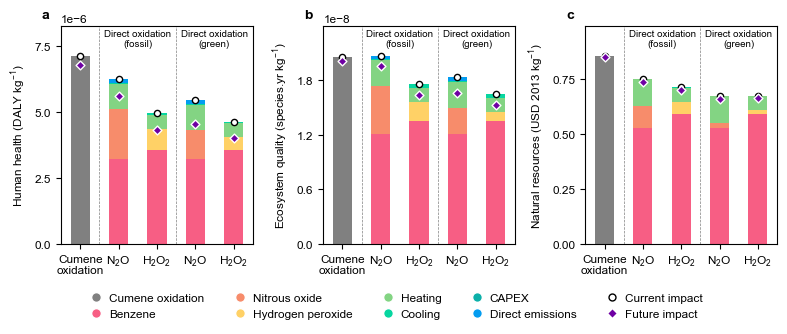

In [99]:
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize = (fig_length[2]*1.1, fig_height*0.3))

hh_phenol_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_phenol, alpha=1)
ax1.legend([], frameon = False)
ax1.set_ylabel('Human health (DALY kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_phenol, hh_phenol_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder=2)
ax1.scatter(x_pts_phenol, hh_phenol_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.set_title('a', fontweight='bold', x = -0.08, fontsize = fontsize_title)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax1.errorbar(
#     x_pts_phenol,
#     hh_phenol_df['Total'],
#     yerr = (hh_phenol_df['Total'] - hh_phenol_df['Low'], hh_phenol_df['High'] - hh_phenol_df['Total']),
#     fmt = 'none',
#     ecolor = '#000000',
#     elinewidth = 0.75,
#     capsize = 3,
#     capthick = 0.75,
#     zorder = 1,
# )
# ax1.set_ylim([0.0, 2.4])
# ax1.text(0, 1.85, 'Cumene\noxidation', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(1.5, 1.85, 'Direct oxidation\n(fossil)', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(3.5, 1.85, 'Direct oxidation\n(green)', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax1.yaxis.set_major_locator(MaxNLocator(4))
ax1.set_xticks(x_pts_phenol)  
ax1.set_xticklabels(x_labels_phenol, rotation = 0, ha = 'center')  
min_y, max_y = ax1.get_ylim()
ax1.set_ylim([min_y, max_y*1.1])
ax1.text(1.5, max_y, 'Direct oxidation\n(fossil)', ha = 'center', color = '#000000', fontsize=7)
ax1.text(3.5, max_y, 'Direct oxidation\n(green)', ha = 'center', color = '#000000', fontsize=7)

es_phenol_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors_phenol, alpha=1)
ax2.legend([], frameon = False)
ax2.set_ylabel('Ecosystem quality (species.yr kg$^\mathdefault{-1}$)')
ax2.scatter(x_pts_phenol, es_phenol_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder=2)
ax2.scatter(x_pts_phenol, es_phenol_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax2.set_title('b', fontweight='bold', x = -0.08, fontsize = fontsize_title)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax2.errorbar(
#     x_pts_phenol,
#     es_phenol_df['Total'],
#     yerr = (es_phenol_df['Total'] - es_phenol_df['Low'], es_phenol_df['High'] - es_phenol_df['Total']),
#     fmt = 'none',
#     ecolor = '#000000',
#     elinewidth = 0.75,
#     capsize = 3,
#     capthick = 0.75,
#     zorder = 1,
# )
# ax2.set_ylim([0, 8.2])
# ax2.text(0, 6.8, 'Cumene\noxidation', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax2.text(1.5, 6.8, 'Direct oxidation\n(fossil)', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax2.text(3.5, 6.8, 'Direct oxidation\n(green)', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_xticks(x_pts_phenol)  
ax2.set_xticklabels(x_labels_phenol, rotation = 0, ha = 'center')  
min_y, max_y = ax2.get_ylim()
ax2.set_ylim([min_y, max_y*1.1])
ax2.text(1.5, max_y, 'Direct oxidation\n(fossil)', ha = 'center', color = '#000000', fontsize=7)
ax2.text(3.5, max_y, 'Direct oxidation\n(green)', ha = 'center', color = '#000000', fontsize=7)

nr_phenol_df_final.plot(kind = 'bar', stacked = True, ax = ax3, color = colors_phenol, alpha=1)
ax3.legend([], frameon = False)
ax3.set_ylabel('Natural resources (USD 2013 kg$^\mathdefault{-1}$)')
ax3.scatter(x_pts_phenol, nr_phenol_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder=2)
ax3.scatter(x_pts_phenol, nr_phenol_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax3.set_title('c', fontweight='bold', x = -0.08, fontsize = fontsize_title)
ax3.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax3.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax3.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax3.errorbar(
#     x_pts_phenol,
#     nr_phenol_df['Total'],
#     yerr = (nr_phenol_df['Total'] - nr_phenol_df['Low'], nr_phenol_df['High'] - nr_phenol_df['Total']),
#     fmt = 'none',
#     ecolor = '#000000',
#     elinewidth = 0.75,
#     capsize = 3,
#     capthick = 0.75,
#     zorder = 1,
# )
# ax3.set_ylim([0, 1.5])
# ax3.text(0, 1.2, 'Cumene\noxidation', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax3.text(1.5, 1.2, 'Direct oxidation\n(fossil)', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax3.text(3.5, 1.2, 'Direct oxidation\n(green)', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax3.yaxis.set_major_locator(MaxNLocator(4))
ax3.set_xticks(x_pts_phenol)
ax3.set_xticklabels(x_labels_phenol, rotation = 0, ha = 'center')
min_y, max_y = ax3.get_ylim()
ax3.set_ylim([min_y, max_y*1.1])
ax3.text(1.5, max_y, 'Direct oxidation\n(fossil)', ha = 'center', color = '#000000', fontsize=7)
ax3.text(3.5, max_y, 'Direct oxidation\n(green)', ha = 'center', color = '#000000', fontsize=7)

labels = ['Cumene oxidation', 'Benzene', 'Nitrous oxide', 'Hydrogen peroxide', 'Heating', 'Cooling', 'CAPEX', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7, alpha=1, linewidth=0.0) for color in colors_phenol]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'burden_shifting', 'phenol_production')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

# filepath = os.path.join('..', 'results', 'plots', 'edited', 'nitrous_oxide_vs_hydrogen_peroxide_edited')
# plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
# plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)